# Continuous Control

---

This notebook is the report component of the third project of the Udacity Deep Reinforcement Learning Nanodegree. The goal is to move a double jointed arm to different target locations. More details on the environment and the scoring criteria can be found in the README.md file. In this report, we will discuss the results of training the agents in this project, including details about the algorithm and hyperparameters used.

### Training Algorithm

To solve this environment, I implemented the [DDPG algorithm](https://arxiv.org/abs/1509.02971). This is an off-policy actor-critic algorithm that uses deep neural networks to represent the policy (actor) and value function (critic). The actor network takes in the state of the environment and outputs an action, while the critic takes in the state and action for all agents simultaneously and outputs an estimate of the value function.

In more detail, the training loop in this algorithm consists of reading experiences from the replay buffer and obtaining the target Q-values for the critic update from each experience. The critic is updated by minimizing the error between the observed and predicted Q-values. The actor is updated by maximizing the return predicted by the critic. The target networks are updated with soft updates, ensuring that they track behind the main networks. The replay buffer stores experience rollouts from the environment. After each episode, this training loop is done for a number of iterations proportional to the length of the episode, ensuring that the agent learns more after longer episodes that likely contain better information. Each iteration consists of performing this update loop on a randomly sampled batch of experiences from the replay buffer.

We also use warmup episodes and a noise process to encourage exploration. During the warmup episodes, the agent takes random actions. Then, we add noise to the actions taken by the actor to make the training more robust as well. As the score increases, we reduce the amount of noise added to the actions, as the agent should be able to learn more from it's own experiences rather than random actions.

The best actor and critic networks generated during training are saved as `best_actor.pth` and `best_critic.pth`, respectively.

### Avenues for Future Work

- Extending the current implementation to use the MADDPG algorithm on the environment with multiple arms.
- Along with the above, combining experiences of agents that occurred separately but can be used to train every agent.
- Use prioritized experience replay, which samples better experiences more frequently to speed up training.


## Project Architecture

The project consists of the following files (aside from the ones required for the environment):

- `main.py`: The main training script. This is where the training loop is implemented
- `actor.py`: The implementation of the actor network, a neural network in torch.
- `critic.py`: The implementation of the critic network, a neural network in torch.
- `replay_buffer.py`: The implementation of the replay buffer.

Note that the target actor and target critic are separate instances of the same classes used for the local actor and critic, and thus these instances all have the same architecture. The architectures for each are described here.

### Actor Network

The actor network is three fully connected layers, an input layer, a hidden layer, and an output layer. The input layer has dimension 33, which is the size of the state space for the agent in this environment. The hidden layer has dimension 256, and the output layer has dimension 4, the size of the action space for the agent. The first layer uses layer normalization with ReLU activation, the second layer uses just ReLU, and the output layer uses a tanh activation function so the output actions are in the range [-1, 1]. The final layer of the actor network is initialized with uniform weights near zero.

### Critic Network

Similar to the actor network, the critic network is three fully connected layers. The input layer has dimension 33, which is the size of the state space. The hidden layer has dimension 256 and additionally takes in the actions for both agents, which has dimension 4. The output layer just has dimension 1, since it just outputs the estimate of the value function. The first layer uses batch normalization with ReLU activation, the second layer just uses ReLU, and the output layer is initialized with uniform weights near zero.

### Replay Buffer

A standard implementation of the replay buffer, discarding the oldest experience once the buffer is full.

## Training Details

In this section we will demonstrate the training process and show the results. **This notebook is configured for the 20-agent Reacher environment.** The training will run according to the parameter values in the snippet below. The environment is considered solved when the average score (over 100 consecutive episodes, averaged across all 20 agents) reaches +30.0.

Once completed, run the cell after to plot the scores obtained during training.

In [1]:
from main import AgentHarness
from unityagents import UnityEnvironment

path = R"C:\Users\eliot\Documents\GitHub\deep_rl_project_2\Reacher_Windows_x86_64\Reacher.exe"
# Run headless to reduce Unity rendering overhead.
env = UnityEnvironment(file_name=path, worker_id=1, no_graphics=True)

# Hyperparameters for training (tuned for 20-agent environment with step-based training)
# Device is auto-selected in AgentHarness: CUDA if available, otherwise CPU.
scores = AgentHarness(
    replay_buffer_max_size=100_000,
    score_window_max_size=100,
    discount_factor=0.99,
    actor_lr=1e-4,
    critic_lr=1e-4,
    replay_buffer_sample_size=64,
    actor_action_l2_coef=1e-3,         # Re-enabled moderate action regularization
    policy_delay=3,
).rollout(
    env,
    num_episodes=10_000,
    noise_decay=0.998,
    exit_on_solve=True,
    learn_every=30,
    num_updates_per_learn=10,
)

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_speed -> 1.0
		goal_size -> 5.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Rollout:   0%|          | 0/10000 [00:00<?, ?it/s]

Environment solved at episode 644 with avg score 30.13!


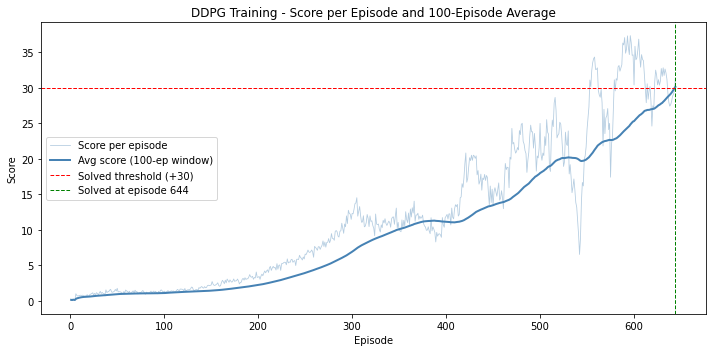

Environment solved in 644 episodes.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

scores_arr = np.array(scores)
episodes = np.arange(1, len(scores_arr) + 1)

# Compute 100-episode rolling average
avg_scores = np.array([
    scores_arr[max(0, i - 99): i + 1].mean()
    for i in range(len(scores_arr))
])

solved_ep = next((i + 1 for i, s in enumerate(avg_scores) if s >= 30.0), None)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(episodes, scores_arr, linewidth=0.8, alpha=0.4, color="steelblue", label="Score per episode")
ax.plot(episodes, avg_scores, linewidth=2, color="steelblue", label="Avg score (100-ep window)")
ax.axhline(y=30.0, color="red", linestyle="--", linewidth=1, label="Solved threshold (+30)")

if solved_ep is not None:
    ax.axvline(x=solved_ep, color="green", linestyle="--", linewidth=1,
               label=f"Solved at episode {solved_ep}")

ax.set_xlabel("Episode")
ax.set_ylabel("Score")
ax.set_title("DDPG Training - Score per Episode and 100-Episode Average")
ax.legend()
plt.tight_layout()
plt.show()

if solved_ep:
    print(f"Environment solved in {solved_ep} episodes.")
